🚀 BẮT ĐẦU TẢI VÀ ĐÁNH GIÁ TỔNG THỂ DỮ LIỆU...

✅ Tải dữ liệu thành công. Kích thước: 30229 dòng x 12 cột.

--------------------------------------------------
PHẦN 1: ĐÁNH GIÁ MỨC ĐỘ KHUYẾT THIẾU DỮ LIỆU
--------------------------------------------------
INSIGHT: Các vùng màu trắng trên bản đồ nhiệt thể hiện dữ liệu bị mất.
RỦI RO: Nếu một cột có quá nhiều mảng trắng (như House direction, Balcony direction), việc đưa vào mô hình sẽ gây nhiễu nghiêm trọng.


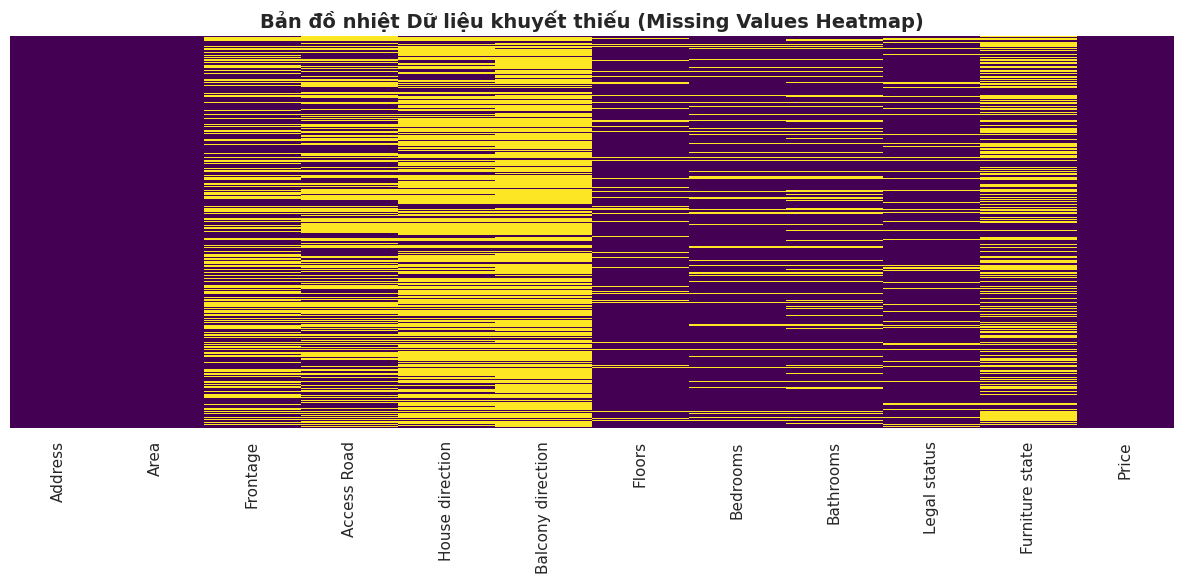

--------------------------------------------------
PHẦN 2: ĐÁNH GIÁ PHÂN PHỐI BIẾN MỤC TIÊU (PRICE)
--------------------------------------------------
INSIGHT: Độ lệch (Skewness) của Price = -0.03.


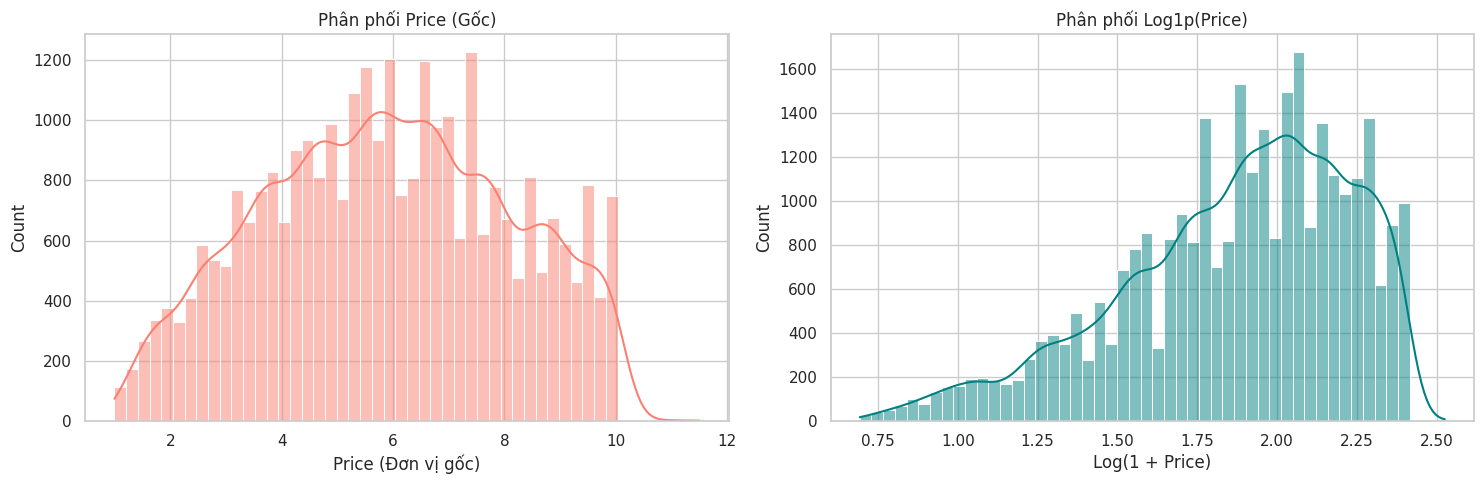

--------------------------------------------------
PHẦN 3: KIỂM ĐỊNH GIÁ TRỊ CỰC ĐOAN BIẾN PRICE (YÊU CẦU CỦA DATA LEAD)
--------------------------------------------------


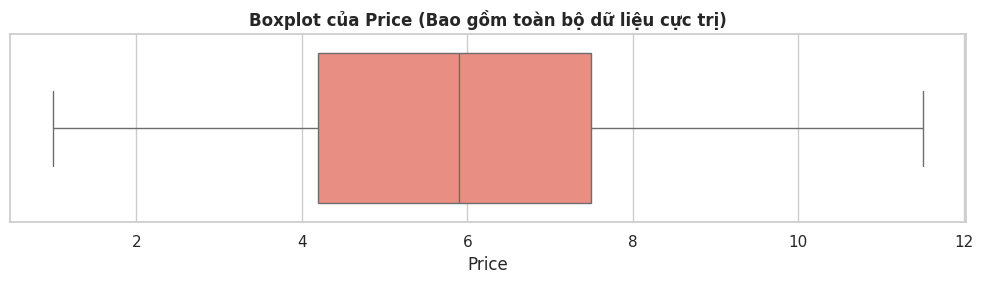

Ngưỡng giới hạn trên (Upper Bound): 12.45
Phát hiện 0 bất động sản có giá vượt ngưỡng (Cực đoan).

🔍 TOP 15 GIAO DỊCH ĐẮT NHẤT ĐỂ ĐỐI CHIẾU CHÉO:


,Price,Area,Price_per_m2,Address



📋 KẾT LUẬN & HÀNH ĐỘNG HỆ THỐNG:
1. LỖI NHẬP LIỆU: Cột 'Price_per_m2' cao phi logic (VD: hàng tỷ/m2) tại khu vực bình dân -> Sai đơn vị. Cần loại bỏ (Drop).
2. NHÀ SIÊU SANG: 'Price' cực cao nhưng 'Area' tỷ lệ thuận, 'Price_per_m2' hợp lý -> Giao dịch thật. BẮT BUỘC GIỮ LẠI để bảo toàn dữ liệu phân khúc cao cấp.

--------------------------------------------------
PHẦN 4: ĐÁNH GIÁ ĐA CỘNG TUYẾN & TƯƠNG QUAN ĐẶC TRƯNG
--------------------------------------------------
INSIGHT: Các ô màu càng sáng/đậm thể hiện quan hệ tuyến tính càng mạnh.
RỦI RO: Nếu có 2 feature tương quan quá cao với nhau (VIF cao), cần cảnh giác hiện tượng đa cộng tuyến (Multicollinearity).


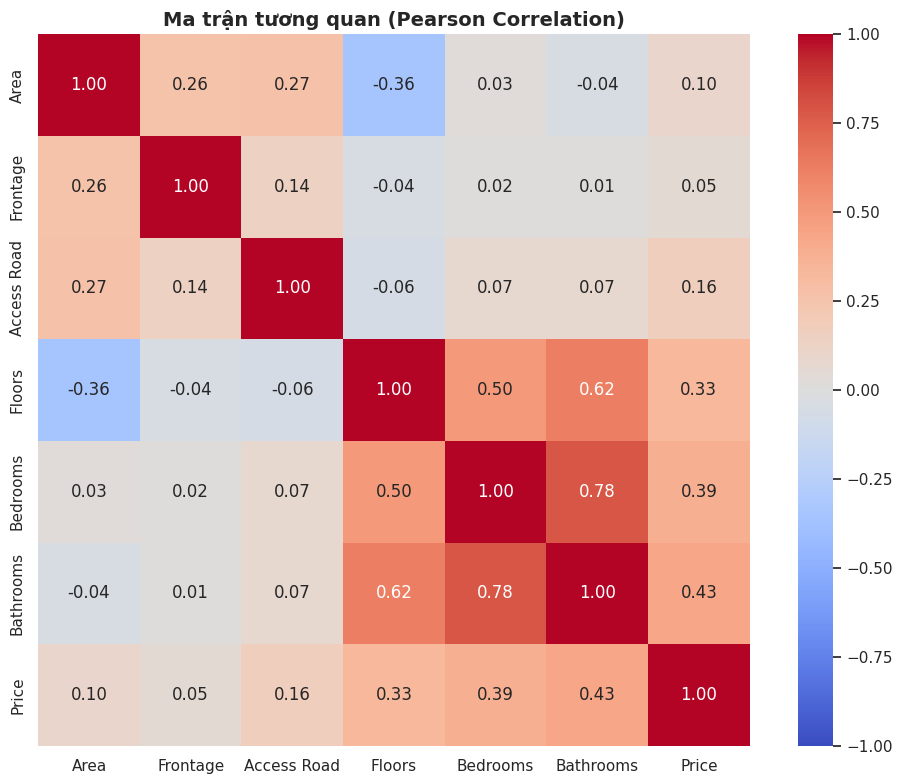

--------------------------------------------------
PHẦN 5: ĐÁNH GIÁ TƯƠNG QUAN LOGIC VẬT LÝ (DIỆN TÍCH - GIÁ)
--------------------------------------------------
INSIGHT: Biểu đồ đã tạm ẩn 1% dữ liệu ngoại lai (nhóm đã kiểm định ở Phần 3) để hiển thị rõ dạng phân tán của cụm dữ liệu chính.
ĐÁNH GIÁ: Cấu trúc điểm dữ liệu hướng lên xác nhận Area và Price có tương quan tuyến tính thuận, phù hợp với vật lý thực tế.


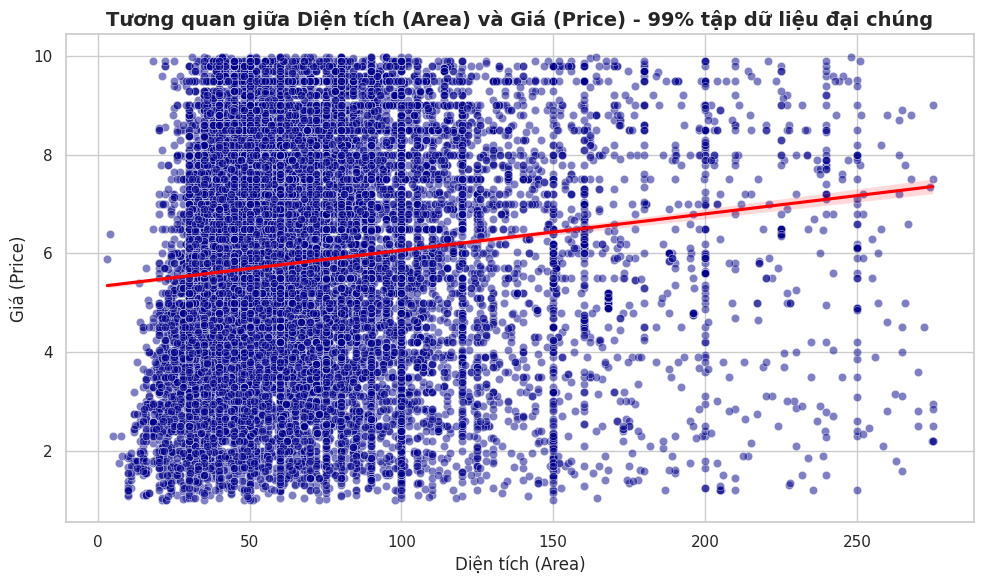

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Tắt cảnh báo để output trên Colab sạch sẽ
warnings.filterwarnings('ignore')

print("🚀 BẮT ĐẦU TẢI VÀ ĐÁNH GIÁ TỔNG THỂ DỮ LIỆU...\n")

# ==========================================
# KHỞI TẠO VÀ TẢI DỮ LIỆU
# ==========================================
url = "https://raw.githubusercontent.com/khoa-nhd/AIQS-Real-Estate-Price-Prediction/refs/heads/main/data/vietnam_housing_dataset.csv"
try:
    df = pd.read_csv(url)
    print(f"✅ Tải dữ liệu thành công. Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột.\n")
except Exception as e:
    print(f"❌ LỖI TẢI DỮ LIỆU: {e}")
    raise

# Thiết lập phong cách đồ họa chung
sns.set_theme(style="whitegrid")
plt.rcParams['figure.autolayout'] = True

# Tạo bản sao dữ liệu sạch Price để sử dụng cho các phân tích liên quan đến giá
df_price = df.dropna(subset=['Price']).copy()

# ==========================================
# PHẦN 1: BỨC TRANH KHUYẾT THIẾU DỮ LIỆU (MISSING VALUES)
# ==========================================
print("-" * 50)
print("PHẦN 1: ĐÁNH GIÁ MỨC ĐỘ KHUYẾT THIẾU DỮ LIỆU")
print("-" * 50)
print("INSIGHT: Các vùng màu trắng trên bản đồ nhiệt thể hiện dữ liệu bị mất.")
print("RỦI RO: Nếu một cột có quá nhiều mảng trắng (như House direction, Balcony direction), việc đưa vào mô hình sẽ gây nhiễu nghiêm trọng.")

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Bản đồ nhiệt Dữ liệu khuyết thiếu (Missing Values Heatmap)', fontsize=14, fontweight='bold')
plt.show()

# ==========================================
# PHẦN 2: PHÂN TÍCH ĐỘ LỆCH CỦA BIẾN MỤC TIÊU (PRICE)
# ==========================================
print("-" * 50)
print("PHẦN 2: ĐÁNH GIÁ PHÂN PHỐI BIẾN MỤC TIÊU (PRICE)")
print("-" * 50)

skewness = df_price['Price'].skew()
print(f"INSIGHT: Độ lệch (Skewness) của Price = {skewness:.2f}.")
if skewness > 1:
    print("ĐÁNH GIÁ: Dữ liệu phân phối lệch phải (Right-Skewed) cực kỳ mạnh do các giao dịch bất động sản cao cấp.")
    print("GIẢI PHÁP HỌC MÁY: Bắt buộc phải dùng biến đổi Log (Log Transformation) trước khi train mô hình tuyến tính để nén đuôi phân phối.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ 1: Phân phối gốc
sns.histplot(df_price['Price'], bins=50, kde=True, color='salmon', ax=axes[0])
axes[0].set_title('Phân phối Price (Gốc)', fontsize=12)
axes[0].set_xlabel('Price (Đơn vị gốc)')

# Biểu đồ 2: Phân phối sau Log
df_price['Log_Price'] = np.log1p(df_price['Price'])
sns.histplot(df_price['Log_Price'], bins=50, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Phân phối Log1p(Price)', fontsize=12)
axes[1].set_xlabel('Log(1 + Price)')
plt.show()

# ==========================================
# PHẦN 3: KIỂM ĐỊNH VÀ THẨM ĐỊNH NGOẠI LAI (OUTLIERS)
# ==========================================
print("-" * 50)
print("PHẦN 3: KIỂM ĐỊNH GIÁ TRỊ CỰC ĐOAN BIẾN PRICE (YÊU CẦU CỦA DATA LEAD)")
print("-" * 50)

# 3.1 Dùng Boxplot nguyên bản để quan sát đuôi phân phối dài
plt.figure(figsize=(10, 3))
sns.boxplot(x=df_price['Price'], color='salmon')
plt.title('Boxplot của Price (Bao gồm toàn bộ dữ liệu cực trị)', fontweight='bold')
plt.xlabel('Price')
plt.show()

# 3.2 Xác định toán học giới hạn cực đoan bằng phương pháp IQR
Q1 = df_price['Price'].quantile(0.25)
Q3 = df_price['Price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

print(f"Ngưỡng giới hạn trên (Upper Bound): {upper_bound:,.2f}")

# 3.3 Cô lập các bất động sản nằm ngoài khoảng giới hạn trên
extreme_df = df_price[df_price['Price'] > upper_bound].copy()
print(f"Phát hiện {extreme_df.shape[0]} bất động sản có giá vượt ngưỡng (Cực đoan).")

# 3.4 THẨM ĐỊNH NGHIỆP VỤ
if 'Area' in extreme_df.columns:
    # Tránh lỗi chia cho 0 bằng cách thay thế tạm thời Area = 0 bằng NaN
    extreme_df['Area'] = extreme_df['Area'].replace(0, np.nan)

    # Tính Đơn giá (Price per m2) - Chìa khóa để phát hiện lỗi
    extreme_df['Price_per_m2'] = extreme_df['Price'] / extreme_df['Area']

    # Thu thập các cột cần thiết để Lead kiểm tra
    cols_to_show = ['Price', 'Area', 'Price_per_m2']
    for loc_col in ['District', 'City', 'Address']:
        if loc_col in extreme_df.columns:
            cols_to_show.append(loc_col)

    print("\n🔍 TOP 15 GIAO DỊCH ĐẮT NHẤT ĐỂ ĐỐI CHIẾU CHÉO:")
    display_df = extreme_df[cols_to_show].sort_values(by='Price', ascending=False).head(15)
    display(display_df)

    print("\n📋 KẾT LUẬN & HÀNH ĐỘNG HỆ THỐNG:")
    print("1. LỖI NHẬP LIỆU: Cột 'Price_per_m2' cao phi logic (VD: hàng tỷ/m2) tại khu vực bình dân -> Sai đơn vị. Cần loại bỏ (Drop).")
    print("2. NHÀ SIÊU SANG: 'Price' cực cao nhưng 'Area' tỷ lệ thuận, 'Price_per_m2' hợp lý -> Giao dịch thật. BẮT BUỘC GIỮ LẠI để bảo toàn dữ liệu phân khúc cao cấp.")
else:
    print("⚠️ Thiếu cột 'Area' để tính đơn giá đối chiếu.")

# ==========================================
# PHẦN 4: MA TRẬN TƯƠNG QUAN TUYẾN TÍNH (CORRELATION MATRIX)
# ==========================================
print("\n" + "-" * 50)
print("PHẦN 4: ĐÁNH GIÁ ĐA CỘNG TUYẾN & TƯƠNG QUAN ĐẶC TRƯNG")
print("-" * 50)
print("INSIGHT: Các ô màu càng sáng/đậm thể hiện quan hệ tuyến tính càng mạnh.")
print("RỦI RO: Nếu có 2 feature tương quan quá cao với nhau (VIF cao), cần cảnh giác hiện tượng đa cộng tuyến (Multicollinearity).")

# Chỉ tính tương quan cho các biến số, dùng df gốc để quét toàn bộ đặc trưng
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Ma trận tương quan (Pearson Correlation)', fontsize=14, fontweight='bold')
plt.show()

# ==========================================
# PHẦN 5: ĐÁNH GIÁ TƯƠNG QUAN LÕI (AREA vs PRICE)
# ==========================================
print("-" * 50)
print("PHẦN 5: ĐÁNH GIÁ TƯƠNG QUAN LOGIC VẬT LÝ (DIỆN TÍCH - GIÁ)")
print("-" * 50)

# Lọc bỏ giá trị rác/cực đoan (trên 99%) chỉ để vẽ biểu đồ nhằm quan sát rõ xu hướng đại chúng
q99_price = df_price['Price'].quantile(0.99)
q99_area = df_price['Area'].quantile(0.99) if 'Area' in df_price.columns else None

if q99_area is not None:
    df_plot = df_price[(df_price['Price'] < q99_price) & (df_price['Area'] < q99_area) & (df_price['Area'] > 0)]

    print("INSIGHT: Biểu đồ đã tạm ẩn 1% dữ liệu ngoại lai (nhóm đã kiểm định ở Phần 3) để hiển thị rõ dạng phân tán của cụm dữ liệu chính.")
    print("ĐÁNH GIÁ: Cấu trúc điểm dữ liệu hướng lên xác nhận Area và Price có tương quan tuyến tính thuận, phù hợp với vật lý thực tế.")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_plot, x='Area', y='Price', alpha=0.5, color='darkblue')
    sns.regplot(data=df_plot, x='Area', y='Price', scatter=False, color='red')

    plt.title('Tương quan giữa Diện tích (Area) và Giá (Price) - 99% tập dữ liệu đại chúng', fontsize=14, fontweight='bold')
    plt.xlabel('Diện tích (Area)')
    plt.ylabel('Giá (Price)')
    plt.show()
else:
    print("⚠️ Cột 'Area' không tồn tại hoặc bị lỗi định dạng, không thể vẽ biểu đồ.")